In [33]:
# Add import 
import sys
import torch 
from torch import nn
from torch import optim
from prodigyopt import Prodigy # proddigy optimizer from https://github.com/konstmish/prodigy?tab=readme-ov-file

import tqdm
import numpy as np
import matplotlib.pyplot as plt
# allow reload of python modules
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
from dataset.RobotPathDataset.normalizer import MinMaxFeatureNormalizer

from model.models import EMA
import copy
import time

# remove all warnings
import warnings
warnings.filterwarnings("ignore")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Hyperparams Constants

In [34]:
epochs = 10
representiation_dim = 256

In [35]:
normalizer = MinMaxFeatureNormalizer()
encoder_normalizer = MinMaxFeatureNormalizer()
CONFIG = {
    # Model configuration
    'representation_dim': representiation_dim, # Dimension of the representation
    'dim_mults':(1,4,8), # Dimension multipliers for hidden layers of the model # (1, 4, 8)
    
    # Encoder configuration
    'embeder_num_of_hidden_layers' : 1,
    'encoder_conditional_dim': representiation_dim//2,
    
    # Hyperparameters for training
    'batch_size': 32,
    'num_epochs': 20,
    'ema': EMA(beta=0.99), # Exponential moving average for the model weights
        ## Optimizer configuration
        'optimizer': Prodigy,
        'optimizer_kwargs': {
            'lr': 1., # ! ONLY FOR PRODIGY OPTIMIZER
            'weight_decay': 0.01, 
            'safeguard_warmup':True,
            'use_bias_correction':True,
            'betas': (0.9, 0.99),
            },
        # Scheduler configuration
        'scheduler': torch.optim.lr_scheduler.CosineAnnealingLR,
        'scheduler_kwargs': {
            # 'gamma': 0.999,
            'T_max': 10, # Total number of iterations
        },
    
    # Hyperparameters for diffusion process
    'noise_steps': 256,
    'normalize': True,
    'normalizer':normalizer,
    'encoder_normalizer':encoder_normalizer,
    'cfg_scale': 3,


    # Dataset specific configuration
    'n_paths_per_world': 500,
    'n_worlds': 30,
    'n_waypoints': 64, # due to the archtechture has to be a number that is a power of 2 
}

# Dataloader

In [36]:
from dataset import RobotPathDataset

In [37]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
device

cuda:0


device(type='cuda', index=0)

### Normalizer

In [38]:
file = 'D:\Desktop\ADLR\RobotPathData\data\SingleSphere02_all.db'
# file = 'D:\Desktop\ADLR\RobotPathData\data\SingleSphere02_one-world.db'
dataset = RobotPathDataset(file, n_paths_per_world=CONFIG['n_paths_per_world'], n_worlds=CONFIG['n_worlds'],  n_waypoints=CONFIG['n_waypoints'],   normalizer=CONFIG['normalizer'])
print(f' sample shape {dataset[0]["path"].shape} with {len(dataset)} samples')
indx_sample = 5
sample = dataset[indx_sample]

world_indx: 221, world_distance_field_images: torch.Size([64, 64])
world_indx: 255, world_distance_field_images: torch.Size([64, 64])
world_indx: 564, world_distance_field_images: torch.Size([64, 64])
world_indx: 677, world_distance_field_images: torch.Size([64, 64])
world_indx: 880, world_distance_field_images: torch.Size([64, 64])
world_indx: 933, world_distance_field_images: torch.Size([64, 64])
world_indx: 977, world_distance_field_images: torch.Size([64, 64])
world_indx: 993, world_distance_field_images: torch.Size([64, 64])
data shape: torch.Size([4000, 64, 2]), min_values: tensor([0, 0], device='cuda:0'), max_values: tensor([10, 10], device='cuda:0'), n_worlds:8, samples: 4000
 sample shape torch.Size([64, 2]) with 4000 samples


In [39]:

np.unique(dataset.worlds_indx)

array([221, 255, 564, 677, 880, 933, 977, 993], dtype=int64)

In [40]:
denormalized_sample = normalizer.denormalize(sample['path'])
denormalized_sample

tensor([[8.0999, 8.3626],
        [8.1688, 8.3445],
        [8.2372, 8.3257],
        [8.3051, 8.3057],
        [8.3727, 8.2842],
        [8.4391, 8.2587],
        [8.5043, 8.2307],
        [8.5680, 8.2000],
        [8.6290, 8.1640],
        [8.6880, 8.1246],
        [8.7449, 8.0822],
        [8.7974, 8.0341],
        [8.8481, 7.9842],
        [8.8981, 7.9337],
        [8.9400, 7.8765],
        [8.9806, 7.8183],
        [9.0109, 7.7540],
        [9.0413, 7.6896],
        [9.0708, 7.6249],
        [9.0945, 7.5579],
        [9.1182, 7.4909],
        [9.1419, 7.4238],
        [9.1710, 7.3591],
        [9.2001, 7.2944],
        [9.2292, 7.2296],
        [9.2389, 7.1598],
        [9.2454, 7.0891],
        [9.2519, 7.0184],
        [9.2585, 6.9477],
        [9.2223, 6.8898],
        [9.1780, 6.8343],
        [9.1337, 6.7787],
        [9.0894, 6.7232],
        [9.0451, 6.6677],
        [9.0008, 6.6122],
        [8.9560, 6.5570],
        [8.9110, 6.5020],
        [8.8661, 6.4470],
        [8.8

In [41]:
WORLD_IMG = sample['world_img'] 

In [42]:
from torch.utils.data import DataLoader
batch_size = CONFIG['batch_size']
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)
# iterate over the dataset
# get the first batch
sample_batch = next(iter(dataloader))


In [43]:
sample_batch['world_indx'].shape

torch.Size([32])

## Loss Functions

### MSE

### ObstacleFreeLoss

In [44]:
from model import ObstacleFreePathLoss, GraphBasedConsistencyLoss
obstacle_avoidance_loss_fn = ObstacleFreePathLoss(normalizer=CONFIG['normalizer'])
graph_based_consistency_loss_fn = GraphBasedConsistencyLoss()

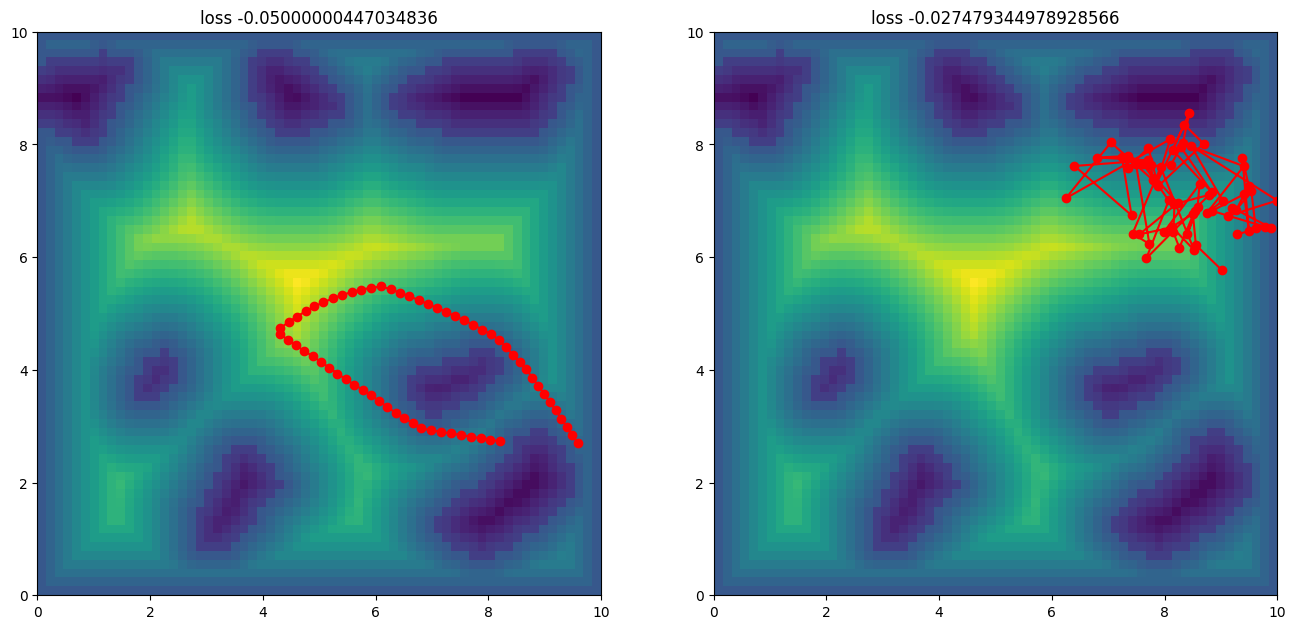

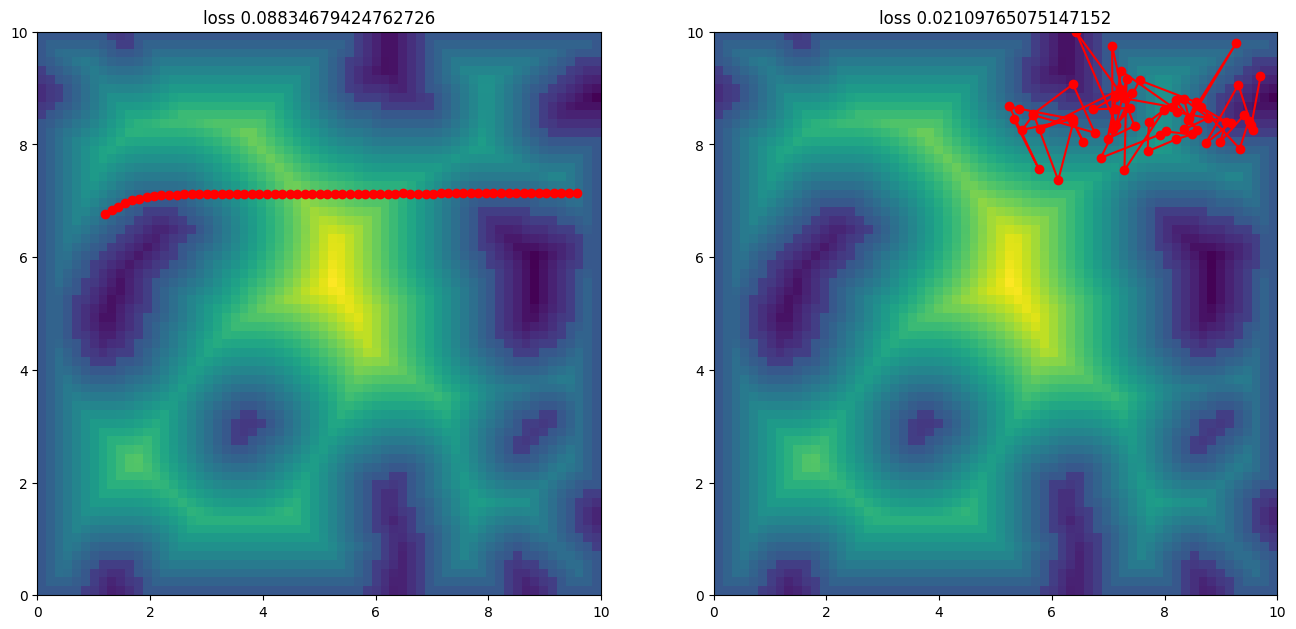

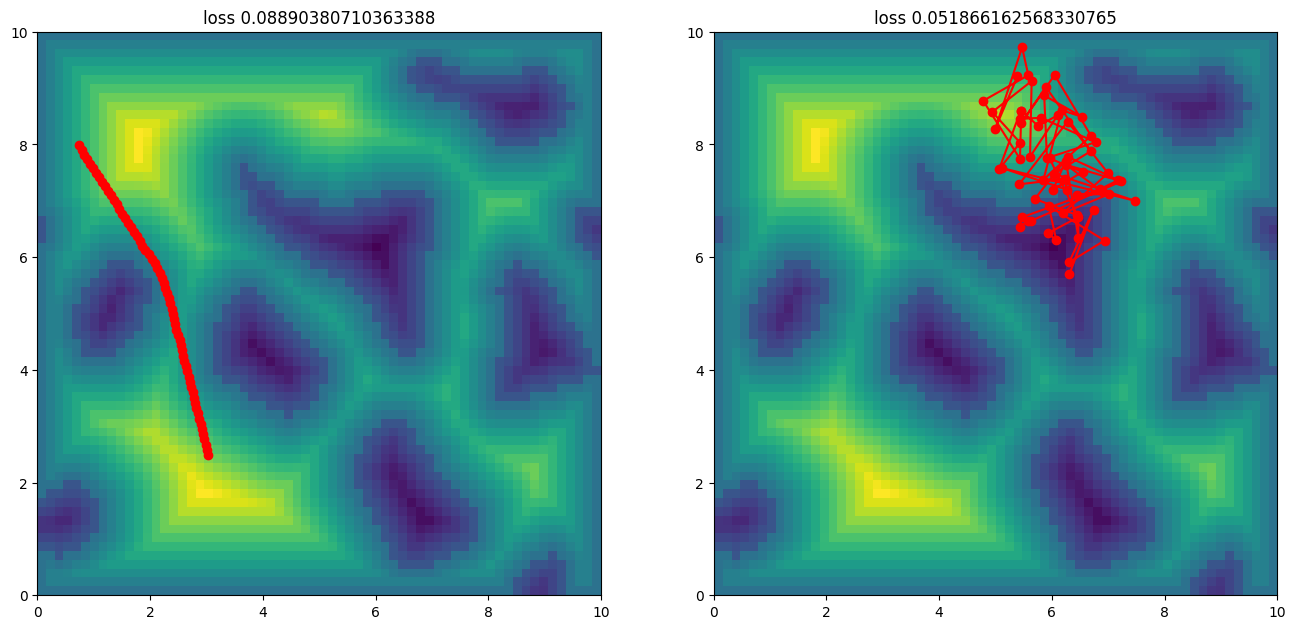

In [45]:
NOISE_TO_ADD_ON_PATH = 0.1
# This loss punishes the model for generating paths that collide with obstacles. 
for i in range(3):
    # create a subpolt for 2 graphs
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    # the 1st will be the path and its distance field + loss value 
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    l = obstacle_avoidance_loss_fn(path, dimg)
    dimg = sample['world_distance_field_img']
    path = sample['og_path'].cpu().detach().numpy()
    axs[0].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[0].plot(path[:, 0], path[:, 1], '-o', color='red')
    axs[0].set_title(f'loss {l}')
    # the 2nd will be the path + some noise and its distance field + loss value
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    noise = torch.randn_like(path) * NOISE_TO_ADD_ON_PATH
    path = path + noise
    l = obstacle_avoidance_loss_fn(path, dimg)
    dimg = sample['world_distance_field_img']
    path_vis = obstacle_avoidance_loss_fn.normalizer.denormalize(path).cpu().detach().numpy()
    axs[1].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[1].plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
    axs[1].set_title(f'loss {l}')

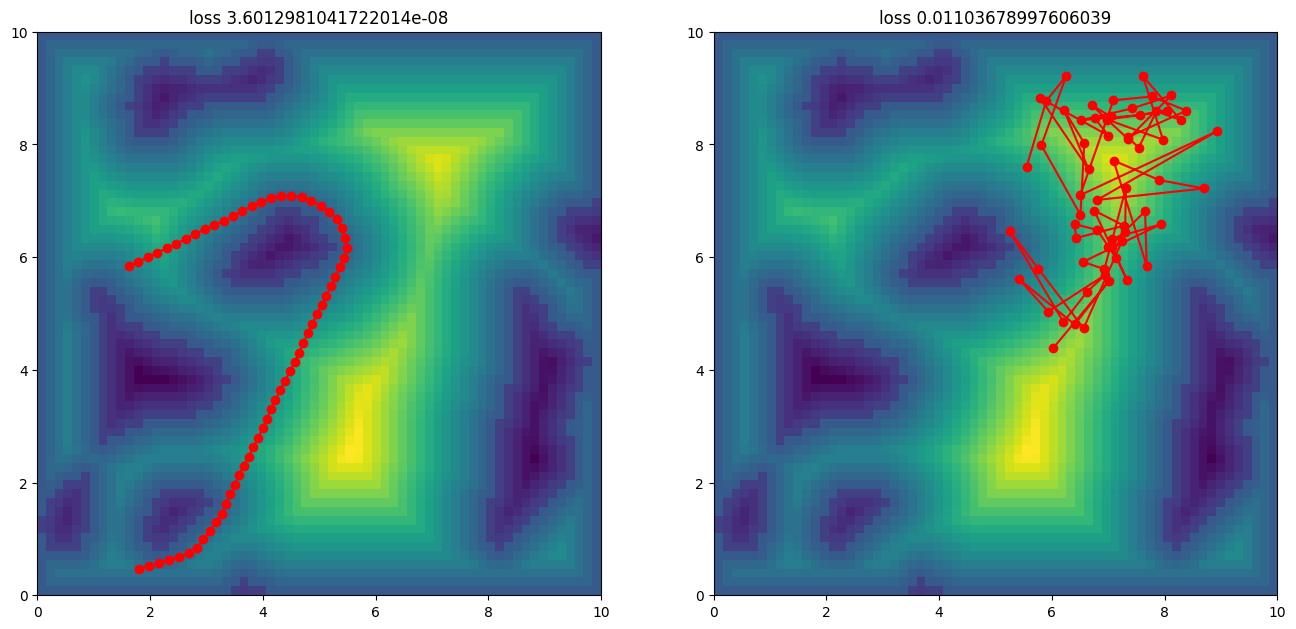

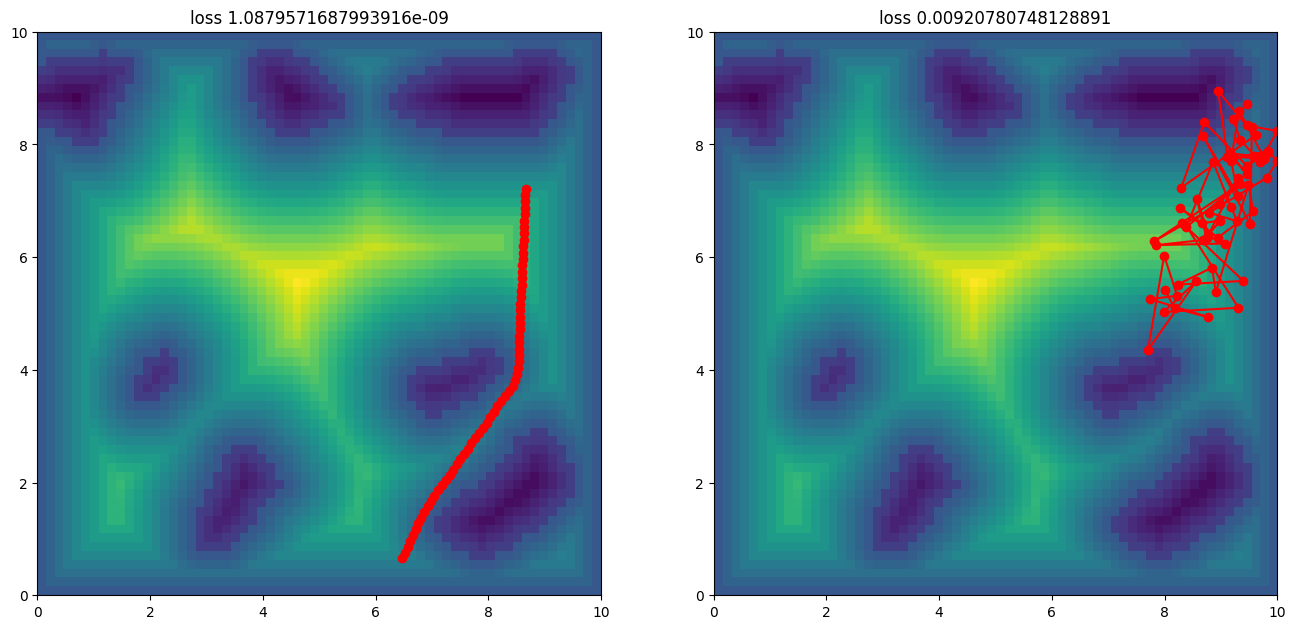

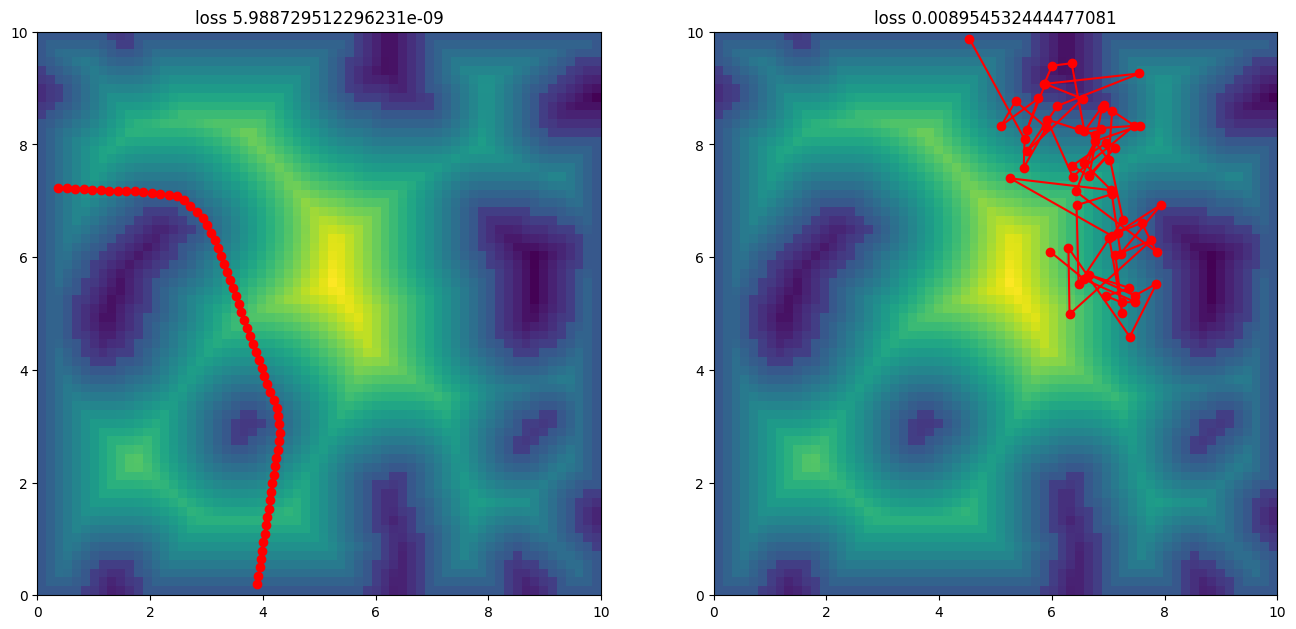

In [46]:
NOISE_TO_ADD_ON_PATH = 0.1
# This loss punishes the model for generating paths that collide with obstacles. 
for i in range(3):
    # create a subpolt for 2 graphs
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))
    # the 1st will be the path and its distance field + loss value 
    indx = np.random.randint(len(dataset))
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    l = graph_based_consistency_loss_fn(path)
    dimg = sample['world_distance_field_img']
    path = sample['og_path'].cpu().detach().numpy()
    axs[0].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[0].plot(path[:, 0], path[:, 1], '-o', color='red')
    axs[0].set_title(f'loss {l}')
    # the 2nd will be the path + some noise and its distance field + loss value
    sample = dataset[indx]
    dimg = sample['world_distance_field_img'].to('cuda')
    path = sample['path']
    path = path.unsqueeze(0)
    dimg = dimg.unsqueeze(0)
    noise = torch.randn_like(path) * NOISE_TO_ADD_ON_PATH
    path = path + noise
    l = graph_based_consistency_loss_fn(path)
    dimg = sample['world_distance_field_img']
    path_vis = obstacle_avoidance_loss_fn.normalizer.denormalize(path).cpu().detach().numpy()
    axs[1].imshow(dimg.T, origin='lower', extent=[0, 10, 0, 10], cmap='viridis')
    axs[1].plot(path_vis[0, :, 0], path_vis[0, :, 1], '-o', color='red')
    axs[1].set_title(f'loss {l}')

# Archtechture

### encoder

In [47]:
from model import WorldIndexEmbeder, FlattenEmbeder

In [48]:
embedding_dim = CONFIG['encoder_conditional_dim']
# Define the model
sample_input = sample['world_distance_field_img']
encoder = FlattenEmbeder(input_sample=sample_input, embedding_dim=embedding_dim, normalizer=None, num_of_hidden_layers=CONFIG['embeder_num_of_hidden_layers'])
encoder

FlattenEmbeder(
  (embedding): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): SELU()
  )
)

### Model and diffusion

In [49]:
from model import Diffusion, TemporalUnet

In [50]:
# Create the UNet
transition_dim = sample['path'].shape[-1] # transition_dim is the dimension the model should predict. not the timesteps
print(transition_dim)
model = TemporalUnet(horizon=CONFIG['noise_steps'], transition_dim=transition_dim, dim=CONFIG['representation_dim'], dim_mults=CONFIG['dim_mults'],encoder=encoder, device=device)

2
[ models/temporal ] Channel dimensions: [(2, 256), (256, 1024), (1024, 2048)]
[ models/temporal ] Embedding dimensions: 128, 32, 32, 64
[(2, 256), (256, 1024), (1024, 2048)]


In [51]:
model.to(device);
model.device

device(type='cuda', index=0)

In [52]:
# create the diffusion model
diffusion = Diffusion(input_shape=sample['path'].shape, noise_steps=CONFIG['noise_steps'], device=device)

In [56]:
# test the model
x = sample_batch
timesteps = diffusion.sample_timesteps(batch_size)
y = model(x['path'], timesteps)
assert y.shape == (batch_size, CONFIG['n_waypoints'], 2)
y.shape

torch.Size([32, 64, 2])

In [57]:
# noise input 
timesteps = diffusion.sample_timesteps(batch_size)
x_t, noise = diffusion.noise_input(sample_batch['path'],timesteps)
x_t.shape, noise.shape

(torch.Size([32, 64, 2]), torch.Size([32, 64, 2]))

In [58]:
import matplotlib.cm as cm

number_of_samples_to_show = 5
# test the model
x = sample_batch['path'][0:number_of_samples_to_show]
timesteps = diffusion.sample_timesteps(number_of_samples_to_show)
y = model(x, timesteps)
# noise input 
timesteps = diffusion.sample_timesteps(number_of_samples_to_show)
x_t, noise = diffusion.noise_input(x,timesteps)
x_t.shape, noise.shape
# plot sample entire batch
colors = cm.rainbow(np.linspace(0, 1, len(x)))
def visualize_diffusion_process(x, x_t, normalizer=None):
    if normalizer:
        x = normalizer.denormalize(x)
        x_t = normalizer.denormalize(x_t)
    x = x.cpu().detach().numpy()
    x_t = x_t.cpu().detach().numpy()
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    for i in range(number_of_samples_to_show):
        ax.plot(x[i, :, 0], x[i, :, 1], 'o-', label='input', color=colors[i])
        ax.plot(x_t[i, :, 0], x_t[i, :, 1], 'o-', label=f'noise t={timesteps[i]}', color=colors[i], alpha=0.5)
    plt.legend()
    plt.show()

print(timesteps)
# visualize_diffusion_process(x, x_t, normalizer=normalizer)
# visualize_diffusion_process(x, x_t, normalizer=None)


tensor([157, 136, 179, 255, 127], device='cuda:0')


# Training

### Set up validation and plotting function

In [59]:
# write training loop 
import torch.optim as optim
import torch.nn as nn


In [60]:
def plot_diffusions(intermediates, world_imgs=None, normalizer=None, max_plots=8, true_paths=None):
    # choose 5 intermediates equally spaced with the last one being at the end indexand 
    intermediates_indx_to_draw = [0, len(intermediates) //4 ,len(intermediates)//2, (3* len(intermediates) ) // 4,len(intermediates)-1]
    if normalizer:
        intermediates = normalizer.denormalize(intermediates, is_numpy=True)
    intermediates = intermediates[intermediates_indx_to_draw]
    intermediates = intermediates.transpose(1,0,2,3)
    if intermediates.shape[0] > max_plots:
        intermediates = intermediates[:max_plots]
        true_paths = true_paths[:max_plots]
        if normalizer:
            true_paths = normalizer.denormalize(true_paths)
    number_of_samples = intermediates.shape[0]
    number_of_steps = intermediates.shape[1]
    fig , ax = plt.subplots(number_of_samples,number_of_steps, figsize=(20,20))
    for i, sample in enumerate(intermediates):
        for j, step in enumerate(sample): 
            ax[i, j].plot(step[:, 0], step[:, 1], 'o-', label='l', color='red')
            if world_imgs is not None:
                ax[i, j].imshow(world_imgs[i].T, extent=[0, 10, 0, 10], origin='lower', cmap='binary')
            if true_paths is not None:
                true_path = true_paths[i].cpu().detach().numpy()
                ax[i, j].plot(true_path[:, 0], true_path[:, 1], 'o-', label='l', color='green', alpha=0.5)
             # put 1st point in green and last point in red
            ax[i, j].plot(step[0, 0], step[0, 1], 'o-', label='start', color='green')
            ax[i, j].plot(step[-1, 0], step[-1, 1], 'o-', label='end', color='yellow')
    plt.tight_layout()
    return fig



In [61]:
def plot_noise_and_predicted_noise(sample, noise, predicted_noise, timesteps, normalizer=None, max_plots=8):

    # if any of the inputs are in the GPU move them to CPU
    if sample.is_cuda:
        sample = sample.clone().cpu().detach().numpy()
    if noise.is_cuda:
        noise = noise.clone().cpu().detach().numpy()
    if predicted_noise.is_cuda:
        predicted_noise = predicted_noise.clone().cpu().detach().numpy()
    if timesteps.is_cuda:
        timesteps = timesteps.clone().cpu().detach().numpy()

    # get per sample differnce betwen noise and predicted noise MSE
    mse_per_sample = np.mean(np.square(noise - predicted_noise), axis=(1, 2))
    sample_plus_noise = sample + noise
    sample_plus_predicted_noise = sample + predicted_noise
    # denormalize the samples
    if normalizer:
        sample = normalizer.denormalize(sample, is_numpy=True)
        sample_plus_noise = normalizer.denormalize(sample_plus_noise, is_numpy=True)
        sample_plus_predicted_noise = normalizer.denormalize(sample_plus_predicted_noise, is_numpy=True)
    if sample.shape[0] > max_plots:
        sample = sample[:max_plots]
        sample_plus_noise = sample_plus_noise[:max_plots]
        sample_plus_predicted_noise = sample_plus_predicted_noise[:max_plots]
        mse_per_sample = mse_per_sample[:max_plots]
        timesteps = timesteps[:max_plots]
    n_cols = 2
    n_rows = sample.shape[0] // n_cols 
    fig, ax = plt.subplots(n_rows , n_cols, figsize=(20, 20))
    for i in range(n_rows):
        for j in range(n_cols):
            ax[i, j].plot(sample[j*n_cols + i, :, 0], sample[j*n_cols + i, :, 1], 'o-', label='input', color='blue')
            ax[i, j].plot(sample_plus_noise[j*n_cols + i, :, 0], sample_plus_noise[j*n_cols + i, :, 1], 'o-', label=f'noised', color='green', alpha=0.5)
            ax[i, j].plot(sample_plus_predicted_noise[j*n_cols + i, :, 0], sample_plus_predicted_noise[j*n_cols + i, :, 1], 'o-', label=f'predicted', color='red', alpha=0.5)
            ax[i, j].set_title(f'MSE={mse_per_sample[j*n_cols + i]:.3f}, t={timesteps[j*n_cols + i]}')  # Title for each subplot

    plt.legend()
    return fig


### Set up LoggingManager

In [62]:
from LoggingManager import LoggingManager
logging_manager = LoggingManager(experiement_name='big-model+spliting the conditioning')
logging_manager.log_config(CONFIG);

Logging to logs\big-model+spliting the conditioning/12h-08m-27-05-2024/logs.log


In [63]:
# log the model and input sample 
input_tensor = sample_batch['path']
cond = sample_batch['world_distance_field_img']
# logging_manager.tb_log_graph(model)

# Train 

In [64]:
START_FROM_CHECKPOINT = False
Checkpoint_file = r"logs/big-model+new obstacle loss/20h-39m-21-05-2024/model-epoch_4-loss_0.100-time_21h-22m-21-05-2024"

In [65]:
# train the model

import random


optimizer = CONFIG['optimizer'](model.parameters(), **CONFIG['optimizer_kwargs'])
scheduler = CONFIG['scheduler'](optimizer, **CONFIG['scheduler_kwargs'])
ema = CONFIG['ema']
ema_model = copy.deepcopy(model).eval().requires_grad_(False)

# Restart from checkpoint 
if START_FROM_CHECKPOINT:
    model, optimizer, scheduler, epoch, loss = logging_manager.load_checkpoint(model, optimizer, scheduler, filename=Checkpoint_file)
    ema.step_ema(ema_model,model)
    logging_manager.log_message(f'Restarting from epoch {epoch} with loss {loss}')
    print(f'Restarting from epoch {epoch} with loss {loss}')


Using decoupled weight decay


RuntimeError: Only Tensors created explicitly by the user (graph leaves) support the deepcopy protocol at the moment.  If you were attempting to deepcopy a module, this may be because of a torch.nn.utils.weight_norm usage, see https://github.com/pytorch/pytorch/pull/103001

In [66]:

for epoch in range(CONFIG['num_epochs']):
    pbar = tqdm.tqdm(dataloader, total=len(dataloader), leave=True)
    running_loss = 0.0
    # iterate over the dataset
    for i, batch_and_info in enumerate(pbar):
        batch, batch_world_indx, batch_world_img, batch_world_distance_field_img = batch_and_info['path'], batch_and_info['world_indx'], batch_and_info['world_img'], batch_and_info['world_distance_field_img']
        

        # Training step
        model.train()
        optimizer.zero_grad()
        x = batch.to(device)
        cond = batch_world_distance_field_img.to(device)
        start_pos = x[:, 0, :]
        end_pos = x[:, -1, :]
        # if random.random() < 0.1: # in 10% of the time. sample unconditional. This is to use CFG
        #     cond = None
        # preturb input. add noise to it
        timesteps_choosen = diffusion.sample_timesteps(x.shape[0])
        x_t, noise = diffusion.noise_input(x,timesteps_choosen)
        # get model to predict the noise
        pred_noise = model(x_t, timesteps_choosen, cond, start_pos, end_pos)
        pred_path = x + pred_noise
    
        
        # Loss 
        loss_noise_prediction = nn.MSELoss()(noise, pred_noise)
        loss_obstacle_avoidance = obstacle_avoidance_loss_fn(pred_path, cond)
        loss = 0.2*loss_noise_prediction + 0.8*loss_obstacle_avoidance
        loss.backward()
        optimizer.step()
        # update the EMA model
        ema.step_ema(ema_model,model)
        running_loss += loss.item()
        logging_manager.plot_losses(loss.item())
        logging_manager.tb_scalar('Loss/MSE', loss_noise_prediction.item())
        logging_manager.tb_scalar('Loss/ObstacleAvoidance', loss_obstacle_avoidance.item())
        pbar.set_postfix({'loss': loss.item()})
        if i % 100 == 0:

            # plot noise and predicted noise
            plot = plot_noise_and_predicted_noise(x, noise, pred_noise, timesteps_choosen, normalizer=CONFIG['normalizer'])
            logging_manager.tb_log_figure(plot, 'noise_and_predicted_noise', step= i + epoch * len(dataloader))

            # plot noise and predicted noise ema
            ema_model.eval()
            pred_noise_ema = ema_model(x_t, timesteps_choosen)
            plot = plot_noise_and_predicted_noise(x, noise, pred_noise_ema, timesteps_choosen, normalizer=CONFIG['normalizer'])
            logging_manager.tb_log_figure(plot, 'ema_noise_and_predicted_noise', step= i + epoch * len(dataloader))
            
            # Log optimizer parameters and scheduler parameters
            logging_manager.tb_scalar('optimizer/learning_rate', optimizer.param_groups[0]['lr'])
            logging_manager.tb_scalar('optimizer/d', optimizer.param_groups[0]['d'])
            logging_manager.tb_scalar('optimizer/scheduler-lr', scheduler.get_lr()[0])
            

            
    
    logging_manager.log_message(f'Epoch {epoch} Epoch loss: {running_loss/len(dataloader)}')
    print(f'Epoch {epoch} Epoch loss: {running_loss/len(dataloader)}')
    # scheduler
    scheduler.step()
    running_loss = 0.0
    # Validation 
    model.eval()




    if epoch% 5 == 0:
        logging_manager.save_checkpoint(model, optimizer, scheduler,epoch, loss)

        time.sleep(5)
        # # sample model
        # sample from paths 
        n = 16
        paths = batch[:n]
        cond = batch_world_distance_field_img[:n]
        true_paths = paths
        samples , intermediates = diffusion.sample_from_paths(model, n=n, paths=paths, cond=cond, normalizer=CONFIG['normalizer'])
        plot = plot_diffusions(intermediates, world_imgs=batch_world_img, normalizer=CONFIG['normalizer'], true_paths=true_paths);
        logging_manager.tb_log_figure(plot, 'diffusion_samples', step=epoch)
        # samples, intermediates = diffusion.sample(ema_model,5, cfg_scale=CONFIG['cfg_scale'])
        # plot = plot_diffusions(intermediates, normalizer=CONFIG['normalizer'])
        # logging_manager.tb_log_figure(plot, 'diffusion_samples_ema_cfg', step=epoch)
        for k in range(1):
            
            last_index_for_waypoints = CONFIG['n_waypoints'] - 1
            constraints = {
                0: torch.tensor([0, 0], device=device),
                last_index_for_waypoints: torch.tensor([9, 9],device=device),
            }
            n=CONFIG['batch_size']
            cond = batch_world_distance_field_img.to(device)
            world_imgs = batch_world_img
            # logging_manager.log_message(f'Generating samples from edge to edge with worlds {batch_world_indx}')
            # samples, intermediates = diffusion.sample_with_constraints(model, n=n, constraints=constraints, cond=cond,normalizer=CONFIG['normalizer'])
            # plot = plot_diffusions(intermediates, world_imgs=world_imgs, normalizer=CONFIG['normalizer']);
            # logging_manager.tb_log_figure(plot, f'samples edge to edge World {k}', step=epoch);
            # sample ema model with cfg
            # samples, intermediates = diffusion.sample_with_constraints(ema_model, n=n, constraints=constraints, cond=cond, normalizer=CONFIG['normalizer'], cfg_scale=CONFIG['cfg_scale'])
            # plot = plot_diffusions(intermediates, world_imgs=world_imgs, normalizer=CONFIG['normalizer']);
            # logging_manager.tb_log_figure(plot, f'samples edge to edge World {k} ema+cfg', step=epoch);
            
        # log model embedding space
        # features = model.get_last_embedding()
        # metadata = batch_world_indx
        # metadata should be a list of strings
        # metadata = [f'world {str(i)}' for i in metadata]
        # images = batch_world_img # batch * 64 * 64
        # images = images.unsqueeze(1) # turn to batch * C * H * W
        # logging_manager.tb_log_embedding_space(features, metadata, images)
        
        # # log model weights
        # last_layer_weights = model.final_conv[-1].weight
        # logging_manager.tb_log_histogram(last_layer_weights, 'final layer wieghts')
        # # log model embedding space weights
        # embedding_weights = model.encoder.embedding[-2].weight
        # logging_manager.tb_log_histogram(embedding_weights, 'embedding layer wieghts')
 
        
        
print('Finished Training')    

  1%|          | 1/125 [00:08<16:50,  8.15s/it, loss=0.22]


KeyboardInterrupt: 

In [ ]:
constraints = {
    0: torch.tensor([0, 0], device=device),
    99: torch.tensor([9, 9],device=device),
}
# choose 1 random world
random_world_indx= 5
# sample n samples from this world
n=5
world_distance_field_img = dataset[random_world_indx]['world_distance_field_img']
world_img = dataset[random_world_indx]['world_img']
# create a batch of 5 of this world
cond = world_distance_field_img.unsqueeze(0).repeat(n,1,1).to(device)
cond.shape

In [ ]:
world_imgs = [world_img for i in range(n)]
samples, intermediates = diffusion.sample_with_constraints(model, n=n, constraints=constraints,normalizer=CONFIG['normalizer'], cond=cond)
plot = plot_diffusions(intermediates, world_imgs=world_imgs, normalizer=CONFIG['normalizer'])
logging_manager.tb_log_figure(plot, f'sampling with constraints', step=1)

In [ ]:
plot

In [ ]:
# Get a real path from the dataset and use it's start and end point as constraints then plot both besides each other
random_indx = random.randint(0, len(dataset))
item = dataset.get_og_item(random_indx)
real_path = item['path']
starting_point = real_path[0]
end_point = real_path[-1]
world_img = item['world_img']
world_imgs = [world_img for i in range(n)]
world_distance_field_img = item['world_distance_field_img']
cond = world_distance_field_img.unsqueeze(0).repeat(n,1,1).to(device)
cond.shape , random_indx

In [ ]:
constraints = {
    0: starting_point,
    99: end_point,
}
samples, intermediates = diffusion.sample_with_constraints(model, n=n, constraints=constraints,normalizer=CONFIG['normalizer'], cond=cond)
plot = plot_diffusions(intermediates, world_imgs=world_imgs, normalizer=CONFIG['normalizer'])

In [ ]:
# plot the real path
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
real_path = real_path.cpu().detach().numpy()
ax.plot(real_path[:, 0], real_path[:, 1], 'o-', label='real path', color='blue')
ax.imshow(world_img.T, extent=[0, 10, 0, 10], origin='lower', cmap='binary')
plt.legend()

In [ ]:
logging_manager.save_checkpoint(model, optimizer, scheduler,epoch, loss)

In [ ]:
# # Save final model
torch.save(model.state_dict(), 'model.pth')

# Sample Model

In [ ]:

logging_manager.save_checkpoint(model, optimizer, scheduler,epoch, loss)

INFO:LoggingManager:Checkpoint saved to logs\big-model+new obstacle loss/17h-40m-21-05-2024\model-epoch_0-loss_0.076-time_18h-23m-21-05-2024


In [ ]:
# create constraints dict 
constraints = {
    0: torch.tensor([0, 0], device=device),
    10: torch.tensor([8, 8],device=device),
    19: torch.tensor([1, 1],device=device),
}
# sample from final model
samples, intermediates = diffusion.sample_with_constraints(model, 10, constraints, normalizer=CONFIG['normalizer'])
plot = plot_diffusions(intermediates, world_img=WORLD_IMG, normalizer=CONFIG['normalizer'])